# 05 — Modeling & Experiment Logging
**Proyek:** Klasifikasi Tingkat Risiko Stroke Berdasarkan Data Klinis dan Gaya Hidup Menggunakan Algoritma TabNet dengan Interpretasi Attention Mechanism

**Tahap:** Modeling

**Tujuan:**
1. Melatih **TabNet** sebagai model utama riset.
2. Melatih 3 baseline klasik: **Logistic Regression**, **Random Forest**, **XGBoost**.
3. Mencatat seluruh eksperimen ke **MLflow** (params, metrics, model artifact, confusion matrix).
4. Mengevaluasi setiap model pada validation & test set dengan metrik:
   `ROC-AUC, F1, Recall, Precision, Accuracy, Confusion Matrix`.
5. Menyimpan run\_id terbaik untuk dipanggil ulang di notebook `06_best_model.ipynb`.

> **Catatan reproducibility:** seluruh model menggunakan `random_state=42` dari `params.yaml` dan dataset hasil `data/processed/tabnet_ready.npz` (sudah di-SMOTE pada training set saja).

## 1. Setup & Imports

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
METRICS_DIR = PROJECT_ROOT / "metadata"
FIG_DIR = REPORTS_DIR / "figures"
for p in [MODELS_DIR, REPORTS_DIR, METRICS_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / "params.yaml") as f:
    params = yaml.safe_load(f)

RANDOM_STATE = params["dataset"]["random_state"]
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RANDOM_STATE :", RANDOM_STATE)
print("Device       :", "cuda" if torch.cuda.is_available() else "cpu")

PROJECT_ROOT : /Users/macbookpro/Documents/Kuliah/Semester 6/Proyek Data Mining/Riset Data Mining
RANDOM_STATE : 42
Device       : cpu


## 2. Load Data Hasil Preprocessing

In [2]:
ready = np.load(DATA_PROCESSED / "tabnet_ready.npz")
X_train, y_train = ready["X_train"], ready["y_train"]
X_val,   y_val   = ready["X_val"],   ready["y_val"]
X_test,  y_test  = ready["X_test"],  ready["y_test"]

with open(DATA_PROCESSED / "tabnet_meta.json") as f:
    meta = json.load(f)

feature_names = meta["feature_names"]
cat_idxs = meta["cat_idxs"]
cat_dims = meta["cat_dims"]

print(f"Train : X={X_train.shape}  positives={int(y_train.sum())}")
print(f"Val   : X={X_val.shape}    positives={int(y_val.sum())}")
print(f"Test  : X={X_test.shape}   positives={int(y_test.sum())}")
print(f"\nFitur ({len(feature_names)}):", feature_names)
print(f"cat_idxs : {cat_idxs}")
print(f"cat_dims : {cat_dims}")

Train : X=(5100, 10)  positives=1700
Val   : X=(767, 10)    positives=37
Test  : X=(767, 10)   positives=37

Fitur (10): ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']
cat_idxs : [0, 4, 5, 6, 9]
cat_dims : [2, 2, 5, 2, 4]


## 3. Konfigurasi MLflow

In [3]:
mlflow_cfg = params["mlflow"]
db_path = (PROJECT_ROOT / mlflow_cfg["tracking_db"]).resolve()
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment(mlflow_cfg["experiment_name"])

print("MLflow tracking URI :", mlflow.get_tracking_uri())
print("Experiment          :", mlflow_cfg["experiment_name"])
print("Primary metric      :", mlflow_cfg["primary_metric"])

MLflow tracking URI : sqlite:////Users/macbookpro/Documents/Kuliah/Semester 6/Proyek Data Mining/Riset Data Mining/mlflow.db
Experiment          : stroke-risk-classification
Primary metric      : val_roc_auc


> **Mengapa MLflow?**
> Setiap run otomatis menyimpan params, metrics, dan model artifact. Kita bisa
> membandingkan ratusan eksperimen di UI tanpa harus copy-paste hasil ke
> spreadsheet. Setelah notebook selesai, jalankan `mlflow ui` di terminal lalu
> buka `http://127.0.0.1:5000` untuk melihat dashboard.

## 4. Helper: Evaluasi & Logging

In [4]:
def evaluate(model_name: str, y_true, y_pred, y_proba) -> dict:
    """Hitung metrik utama untuk klasifikasi biner stroke."""
    return {
        "roc_auc":   float(roc_auc_score(y_true, y_proba)),
        "f1":        float(f1_score(y_true, y_pred)),
        "recall":    float(recall_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "accuracy":  float(accuracy_score(y_true, y_pred)),
    }


def log_confusion_matrix(y_true, y_pred, title: str, run_id: str):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Stroke", "Stroke"],
                yticklabels=["No Stroke", "Stroke"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    plt.tight_layout()
    fname = FIG_DIR / f"cm_{title.lower().replace(' ', '_')}.png"
    fig.savefig(fname, dpi=120)
    plt.show()
    mlflow.log_artifact(str(fname), artifact_path="confusion_matrix")
    return cm


def print_metrics(name: str, val_m: dict, test_m: dict):
    print(f"\n=== {name} ===")
    print(f"{'metric':<10}  {'val':>8}   {'test':>8}")
    for k in ["roc_auc", "f1", "recall", "precision", "accuracy"]:
        print(f"{k:<10}  {val_m[k]:>8.4f}   {test_m[k]:>8.4f}")

## 5. Baseline 1 — Logistic Regression

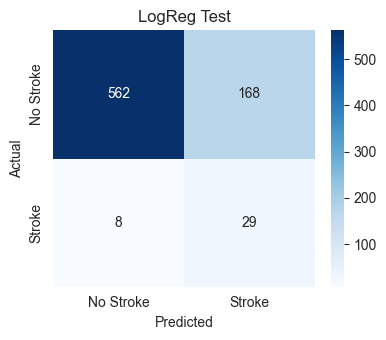

2026/05/10 16:19:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== Logistic Regression ===
metric           val       test
roc_auc       0.8586     0.8173
f1            0.2311     0.2479
recall        0.7838     0.7838
precision     0.1355     0.1472
accuracy      0.7484     0.7705


In [5]:
cfg = params["baselines"]["logreg"]

with mlflow.start_run(run_name="logreg") as run:
    mlflow.set_tag("model_family", "linear")
    mlflow.set_tag("stage", "baseline")
    mlflow.log_params(cfg)
    mlflow.log_param("random_state", RANDOM_STATE)

    model = LogisticRegression(random_state=RANDOM_STATE, **cfg)
    model.fit(X_train, y_train)

    val_pred  = model.predict(X_val)
    val_proba = model.predict_proba(X_val)[:, 1]
    test_pred  = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]

    val_m  = evaluate("logreg", y_val,  val_pred,  val_proba)
    test_m = evaluate("logreg", y_test, test_pred, test_proba)

    for k, v in val_m.items():  mlflow.log_metric(f"val_{k}", v)
    for k, v in test_m.items(): mlflow.log_metric(f"test_{k}", v)

    log_confusion_matrix(y_test, test_pred, "LogReg Test", run.info.run_id)
    mlflow.sklearn.log_model(model, name="model")
    print_metrics("Logistic Regression", val_m, test_m)
    logreg_run_id = run.info.run_id

## 6. Baseline 2 — Random Forest

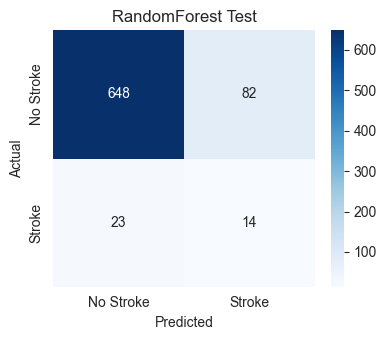

2026/05/10 16:19:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== Random Forest ===
metric           val       test
roc_auc       0.8263     0.7928
f1            0.2158     0.2105
recall        0.4054     0.3784
precision     0.1471     0.1458
accuracy      0.8579     0.8631


: 

In [ ]:
cfg = params["baselines"]["random_forest"]

with mlflow.start_run(run_name="random_forest") as run:
    mlflow.set_tag("model_family", "tree-ensemble")
    mlflow.set_tag("stage", "baseline")
    mlflow.log_params(cfg)
    mlflow.log_param("random_state", RANDOM_STATE)

    model = RandomForestClassifier(random_state=RANDOM_STATE, **cfg)
    model.fit(X_train, y_train)

    val_pred  = model.predict(X_val)
    val_proba = model.predict_proba(X_val)[:, 1]
    test_pred  = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]

    val_m  = evaluate("rf", y_val,  val_pred,  val_proba)
    test_m = evaluate("rf", y_test, test_pred, test_proba)

    for k, v in val_m.items():  mlflow.log_metric(f"val_{k}", v)
    for k, v in test_m.items(): mlflow.log_metric(f"test_{k}", v)

    log_confusion_matrix(y_test, test_pred, "RandomForest Test", run.info.run_id)
    mlflow.sklearn.log_model(model, name="model")
    print_metrics("Random Forest", val_m, test_m)
    rf_run_id = run.info.run_id

## 7. Baseline 3 — XGBoost

In [ ]:
cfg = dict(params["baselines"]["xgboost"])
cfg.pop("use_label_encoder", None)  # deprecated arg di XGBoost 2.x

with mlflow.start_run(run_name="xgboost") as run:
    mlflow.set_tag("model_family", "gradient-boosting")
    mlflow.set_tag("stage", "baseline")
    mlflow.log_params(cfg)
    mlflow.log_param("random_state", RANDOM_STATE)

    model = XGBClassifier(random_state=RANDOM_STATE, **cfg)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    val_pred  = model.predict(X_val)
    val_proba = model.predict_proba(X_val)[:, 1]
    test_pred  = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]

    val_m  = evaluate("xgb", y_val,  val_pred,  val_proba)
    test_m = evaluate("xgb", y_test, test_pred, test_proba)

    for k, v in val_m.items():  mlflow.log_metric(f"val_{k}", v)
    for k, v in test_m.items(): mlflow.log_metric(f"test_{k}", v)

    log_confusion_matrix(y_test, test_pred, "XGBoost Test", run.info.run_id)
    mlflow.xgboost.log_model(model, name="model")
    print_metrics("XGBoost", val_m, test_m)
    xgb_run_id = run.info.run_id

: 

## 8. Model Utama — TabNet
TabNet menggunakan `cat_idxs` & `cat_dims` agar embedding layer internalnya
mempelajari representasi kategorikal sendiri (tidak perlu one-hot).

epoch 0  | loss: 1.01163 | val_auc: 0.57286 |  0:00:00s
epoch 10 | loss: 0.42585 | val_auc: 0.81955 |  0:00:01s
epoch 20 | loss: 0.4132  | val_auc: 0.79456 |  0:00:02s
epoch 30 | loss: 0.39899 | val_auc: 0.79223 |  0:00:04s

Early stopping occurred at epoch 31 with best_epoch = 6 and best_val_auc = 0.84076
Successfully saved model at /tmp/tmp1wpuwpui/tabnet_run.zip

=== TabNet ===
metric           val       test
roc_auc       0.8408     0.8024
f1            0.2357     0.2249
recall        0.8378     0.7568
precision     0.1372     0.1321
accuracy      0.7379     0.7484

Feature importance (TabNet):
age                  0.3789
bmi                  0.1492
work_type            0.1177
Residence_type       0.0900
avg_glucose_level    0.0881
smoking_status       0.0626
gender               0.0439
heart_disease        0.0287
hypertension         0.0205
ever_married         0.0205


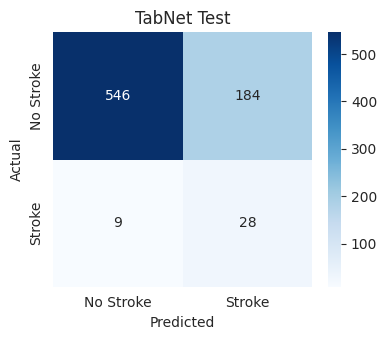

In [ ]:
tn = params["tabnet"]

with mlflow.start_run(run_name="tabnet") as run:
    mlflow.set_tag("model_family", "deep-tabular")
    mlflow.set_tag("stage", "main")
    mlflow.log_params({f"tabnet_{k}": v for k, v in tn.items()})
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("cat_idxs", str(cat_idxs))
    mlflow.log_param("cat_dims", str(cat_dims))

    model = TabNetClassifier(
        n_d=tn["n_d"], n_a=tn["n_a"], n_steps=tn["n_steps"],
        gamma=tn["gamma"], lambda_sparse=tn["lambda_sparse"],
        cat_idxs=cat_idxs, cat_dims=cat_dims, cat_emb_dim=2,
        seed=RANDOM_STATE, verbose=10,
    )

    model.fit(
        X_train=X_train.astype(np.float32), y_train=y_train.astype(np.int64),
        eval_set=[(X_val.astype(np.float32), y_val.astype(np.int64))],
        eval_name=["val"], eval_metric=["auc"],
        max_epochs=tn["max_epochs"], patience=tn["patience"],
        batch_size=tn["batch_size"], virtual_batch_size=tn["virtual_batch_size"],
        num_workers=0, drop_last=False,
    )

    val_pred  = model.predict(X_val.astype(np.float32))
    val_proba = model.predict_proba(X_val.astype(np.float32))[:, 1]
    test_pred  = model.predict(X_test.astype(np.float32))
    test_proba = model.predict_proba(X_test.astype(np.float32))[:, 1]

    val_m  = evaluate("tabnet", y_val,  val_pred,  val_proba)
    test_m = evaluate("tabnet", y_test, test_pred, test_proba)

    for k, v in val_m.items():  mlflow.log_metric(f"val_{k}", v)
    for k, v in test_m.items(): mlflow.log_metric(f"test_{k}", v)
    mlflow.log_metric("best_epoch", int(model.best_epoch))

    # Save TabNet sebagai artifact (zip-format internal pytorch-tabnet)
    # Tulis ke tempdir dulu lalu copy .zip ke models/ — supaya save_model
    # bisa cleanup folder sementaranya tanpa konflik permission.
    import shutil, tempfile
    with tempfile.TemporaryDirectory() as _tmp:
        _tmp_path = Path(_tmp) / "tabnet_run"
        model.save_model(str(_tmp_path))
        tabnet_zip = MODELS_DIR / "tabnet_run.zip"
        shutil.copy(f"{_tmp_path}.zip", tabnet_zip)
    mlflow.log_artifact(str(tabnet_zip), artifact_path="tabnet_model")

    log_confusion_matrix(y_test, test_pred, "TabNet Test", run.info.run_id)

    # Feature importance global dari TabNet
    fi = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    fi_path = REPORTS_DIR / "tabnet_feature_importance.csv"
    fi.to_csv(fi_path, header=["importance"])
    mlflow.log_artifact(str(fi_path), artifact_path="interpretability")

    print_metrics("TabNet", val_m, test_m)
    print("\nFeature importance (TabNet):")
    print(fi.round(4).to_string())
    tabnet_run_id = run.info.run_id

## 9. Ringkasan Eksperimen

In [ ]:
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name(mlflow_cfg["experiment_name"])
runs = client.search_runs(
    [exp.experiment_id],
    order_by=[f"metrics.{mlflow_cfg['primary_metric']} DESC"],
)

rows = []
for r in runs:
    rows.append({
        "run_name":      r.data.tags.get("mlflow.runName", ""),
        "model_family":  r.data.tags.get("model_family", ""),
        "val_roc_auc":   r.data.metrics.get("val_roc_auc"),
        "val_f1":        r.data.metrics.get("val_f1"),
        "val_recall":    r.data.metrics.get("val_recall"),
        "test_roc_auc":  r.data.metrics.get("test_roc_auc"),
        "test_f1":       r.data.metrics.get("test_f1"),
        "test_recall":   r.data.metrics.get("test_recall"),
        "run_id":        r.info.run_id[:8],
    })
leaderboard = pd.DataFrame(rows).sort_values("val_roc_auc", ascending=False).reset_index(drop=True)
leaderboard

In [ ]:
# Simpan ringkasan ke metadata/ untuk dipakai notebook 06
summary_path = METRICS_DIR / "05_modeling_summary.json"
summary = {
    "experiment": mlflow_cfg["experiment_name"],
    "tracking_uri": mlflow_cfg["tracking_uri"],
    "primary_metric": mlflow_cfg["primary_metric"],
    "leaderboard": leaderboard.to_dict(orient="records"),
}
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print("Ringkasan tersimpan di:", summary_path)

Ringkasan tersimpan di: /sessions/wizardly-gallant-keller/mnt/Riset Data Mining/metadata/05_modeling_summary.json


## 10. Catatan
- Seluruh model dilatih pada `X_train` (sudah di-SMOTE) dan dievaluasi pada
  `X_val` & `X_test` yang **murni** (tanpa SMOTE) — agar metrik mencerminkan
  performa pada distribusi nyata.
- Pemilihan model terbaik menggunakan `val_roc_auc` agar tidak overfit ke test
  set; performa final dilaporkan pada test set di notebook `06_best_model.ipynb`.
- Untuk membuka dashboard MLflow:
  ```bash
  mlflow ui --backend-store-uri file:./mlruns
  ```
  Lalu buka `http://127.0.0.1:5000`.